In [8]:
#!pip install seaborn

import sys
sys.path.append('/workspaces/ml-supervised-dev')

import pandas as pd
import numpy as np
from src.utils import carrega_dados, encoding_cols, get_x_y, save_model
import matplotlib.pyplot as plt # Para visualização e plots
import seaborn as sns # Para visualização e plots
%matplotlib inline
pd.set_option('display.max_rows', None) # Define o número máximo de linhas que o Pandas irá apresentar

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Classe do KMeans usada no sklearn
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv('/workspaces/ml-supervised-dev/data/credito.csv')

colunas_numericas = ['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']
df_num = df[colunas_numericas].dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

df_scaled[:5]

array([[-0.05772328, -0.95661321, -0.29108264, -0.28810053, -0.19541334],
       [ 2.29131727, -0.06005053,  0.24419044,  0.74082993, -0.08785188],
       [-0.59182625, -0.8561017 , -0.21632383, -0.49388662, -0.03714433],
       [-0.31085265, -0.64703776,  0.45650546,  0.53504384, -0.19483712],
       [-0.95717631,  0.17414129, -0.15352643, -0.49388662, -0.19541334]])

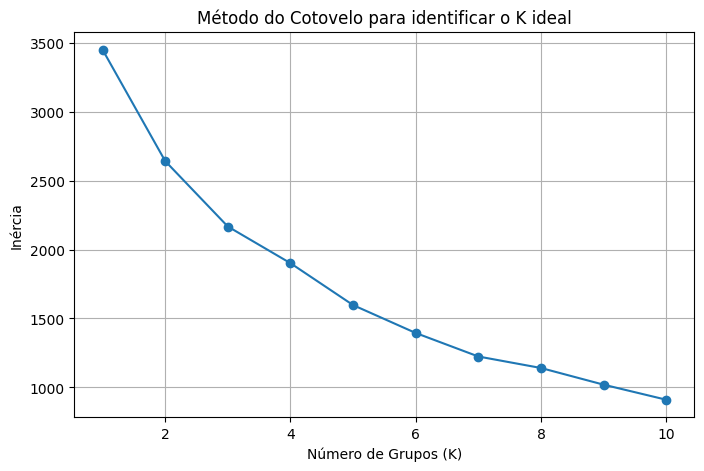

In [10]:
inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercia.append(kmeans.inertia_)

# Gerar o gráfico do Método do Cotovelo para colocar no PDF
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o')
plt.title('Método do Cotovelo para identificar o K ideal')
plt.xlabel('Número de Grupos (K)')
plt.ylabel('Inércia')
plt.grid(True)
plt.show()

In [11]:
k_escolhido = 3 
kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df_num['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Calcular a média das características (incluindo a renda) para cada grupo
analise_grupos = df_num.groupby('Cluster').mean()

print("Características médias de cada grupo:")
print(analise_grupos)

Características médias de cada grupo:
               Age      Debt  YearsEmployed  CreditScore        Income
Cluster                                                               
0        47.248482  9.985759       6.986562     7.321429   1288.598214
1        28.433188  3.715218       1.284172     1.444251    566.703833
2        33.065000  8.145000       3.635000     1.750000  58096.250000


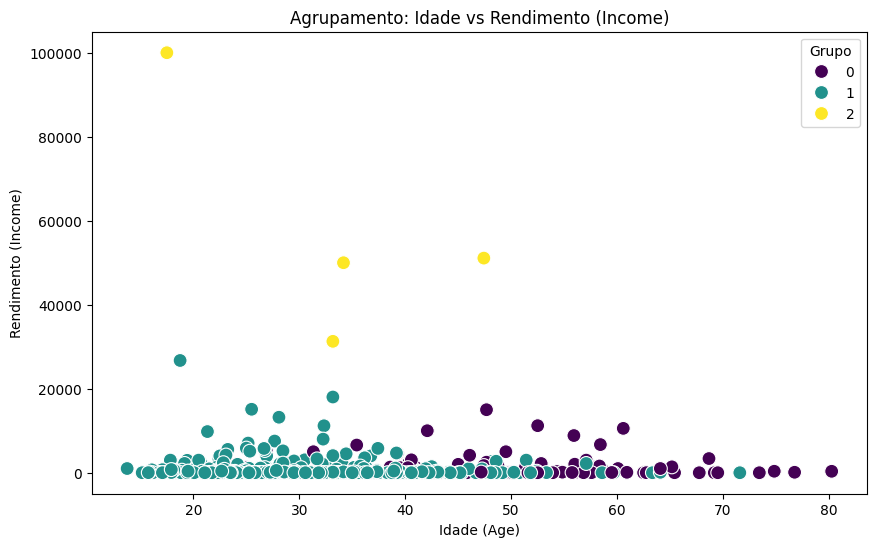

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_num, x='Age', y='Income', hue='Cluster', palette='viridis', s=100)
plt.title('Agrupamento: Idade vs Rendimento (Income)')
plt.xlabel('Idade (Age)')
plt.ylabel('Rendimento (Income)')
plt.legend(title='Grupo')
plt.show()